In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-path/data_path.csv
/kaggle/input/data22/features-gpu-final.csv


In [ ]:

#IMPORT THE LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

#IMPORT THE SKLEARN LIBRARIES
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter



#IMPORT THE KERAS LIBRARIES
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.regularizers import l2
import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
print ("Done")

Done


In [ ]:
# Read the data from the CSV file
df = pd.read_csv('/kaggle/input/data22/features-gpu-final.csv')

# Now you can work with the DataFrame 'df'

In [13]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,193,194,emotion
0,0.182970,0.515045,0.529754,0.608991,0.683982,0.659834,0.569502,0.550935,0.567459,0.547486,...,19.006580,18.431348,43.920981,-0.031129,0.035347,0.030434,-0.033044,0.008114,0.014114,neutral
1,0.241405,0.621877,0.630175,0.712308,0.773238,0.751281,0.658045,0.594538,0.607712,0.588229,...,15.786403,14.451687,13.765523,-0.021032,0.033963,0.028377,-0.030013,-0.000709,0.008721,neutral
2,0.153474,0.582200,0.526100,0.517605,0.591487,0.645550,0.633153,0.590656,0.572146,0.561437,...,19.991799,20.171464,43.320477,0.013674,-0.055683,0.050083,0.040258,0.013969,-0.008002,neutral
3,0.182350,0.514367,0.532612,0.614993,0.684242,0.655253,0.567625,0.553018,0.568303,0.548509,...,18.862923,18.628619,43.987869,-0.039866,0.038383,0.032842,-0.029110,0.008174,0.012371,neutral
4,0.182970,0.515035,0.529736,0.608977,0.683979,0.659833,0.569499,0.550931,0.567459,0.547487,...,19.020104,18.427830,42.621235,-0.031130,0.035355,0.030451,-0.033064,0.008106,0.014115,neutral


In [14]:
# Separate features (X) and labels (Y)
X = df.drop(columns=['emotion']).values  # Features (all columns except 'Emotions')
Y = df['emotion'].values  # Labels (only the 'Emotions' column)

print("Features shape:", X.shape)
print("Labels shape:", Y.shape)

Features shape: (85127, 195)
Labels shape: (85127,)


In [ ]:
# Encode labels (convert strings to integers)
label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)

print("Encoded labels:", Y)
print("Label classes:", label_encoder.classes_)

# save the label encoder for future use
joblib.dump(label_encoder, 'label_encoder.pkl')

Encoded labels: [4 4 4 ... 6 6 6]
Label classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']


In [ ]:
# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (68101, 195)
Testing data shape: (17026, 195)


In [ ]:
# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Save the scaler for future use
joblib.dump(scaler, 'scaler2.pkl')

In [ ]:
# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Class distribution after SMOTE:", Counter(y_train_resampled))

Class distribution after SMOTE: Counter({2: 10817, 4: 10817, 1: 10817, 6: 10817, 5: 10817, 3: 10817, 0: 10817})


In [19]:
# Check class distribution BEFORE/AFTER SMOTE
print("Original class distribution:", Counter(y_train))
print("Resampled class distribution:", Counter(y_train_resampled))

Original class distribution: Counter({1: 10817, 0: 10781, 2: 10761, 3: 10757, 5: 10732, 4: 10570, 6: 3683})
Resampled class distribution: Counter({2: 10817, 4: 10817, 1: 10817, 6: 10817, 5: 10817, 3: 10817, 0: 10817})


In [20]:
# Reshape X_train_resampled and X_test for CNN-RNN input
X_train_resampled = X_train_resampled.reshape(X_train_resampled.shape[0], X_train_resampled.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Verify the new shapes
print("Reshaped X_train_resampled shape:", X_train_resampled.shape)
print("Reshaped X_test shape:", X_test.shape)

Reshaped X_train_resampled shape: (75719, 195, 1)
Reshaped X_test shape: (17026, 195, 1)


In [ ]:
# ===========================
model1 = tf.keras.Sequential([
    # Input Layer
    L.Input(shape=(X_train_resampled.shape[1], 1)),  

    # CNN Layers
    L.Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2),
    L.Dropout(0.3),

    L.Conv1D(256, kernel_size=5, activation='relu', padding='same'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2),
    L.Dropout(0.3),

    L.Conv1D(512, kernel_size=5, activation='relu', padding='same'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=2),
    L.Dropout(0.3),

    # Bidirectional LSTM Layer
    L.Bidirectional(L.LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01))),
    L.Dropout(0.4),

    L.LSTM(64, return_sequences=False),
    L.Dropout(0.4),

    # Fully Connected Layer
    L.Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    L.BatchNormalization(),
    L.Dropout(0.5),

    # Output Layer (7 Emotions)
    L.Dense(7, activation='softmax')  
])

# ===========================
# 3️⃣ Compile Model
# ===========================
# Compile the model
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)                    │ (None, 195, 128)            │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 195, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 97, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 97, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 97, 256)             │         164,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 97, 256)             │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 48, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 48, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ (None, 48, 512)             │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 48, 512)             │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ (None, 24, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 24, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 24, 256)             │         656,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 24, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,572,615 (6.00 MB)

 Trainable params: 1,570,567 (5.99 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
# Define early stocheckpoint_path = "/content/drive/MyDrive/MyModels/best_model.h5"
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
# Save the model when validation loss improves
checkpoint = ModelCheckpoint(
    filepath="/kaggle/working/checkpoint_epoch1_{epoch}.keras",  # Save in Google Drive
    monitor='val_loss',        # Monitor validation loss
    save_best_only=True,       # Save only the best model
    verbose=1
)
# Define learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.2,          # Reduce learning rate by a factor of 0.2
    patience=5,          # Wait for 5 epochs without improvement
    min_lr=1e-6          # Minimum learning rate
)

# Train the model
history = model1.fit(
    X_train_resampled, y_train_resampled,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr,checkpoint]
)

Epoch 1/200
2366/2367 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3411 - loss: 4.7163
Epoch 1: val_loss improved from inf to 1.49316, saving model to /kaggle/working/checkpoint_epoch1_1.keras
2367/2367 ━━━━━━━━━━━━━━━━━━━━ 47s 18ms/step - accuracy: 0.3411 - loss: 4.7145 - val_accuracy: 0.5162 - val_loss: 1.4932 - learning_rate: 0.0010
Epoch 2/200
2365/2367 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5281 - loss: 1.4721
Epoch 2: val_loss improved from 1.49316 to 1.38892, saving model to /kaggle/working/checkpoint_epoch1_2.keras
2367/2367 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.5281 - loss: 1.4721 - val_accuracy: 0.5506 - val_loss: 1.3889 - learning_rate: 0.0010
Epoch 3/200
2366/2367 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5581 - loss: 1.3842
Epoch 3: val_loss did not improve from 1.38892
2367/2367 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.5581 - loss: 1.3842 - val_accuracy: 0.4505 - val_loss: 1.7000 - learning_rate: 0.0010
Epoch 4/200
2366/2367 ━━━━━━━━━━

In [26]:
# Evaluate the model
test_loss, test_accuracy = model1.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

533/533 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9097 - loss: 0.3034
Test Accuracy: 90.83%


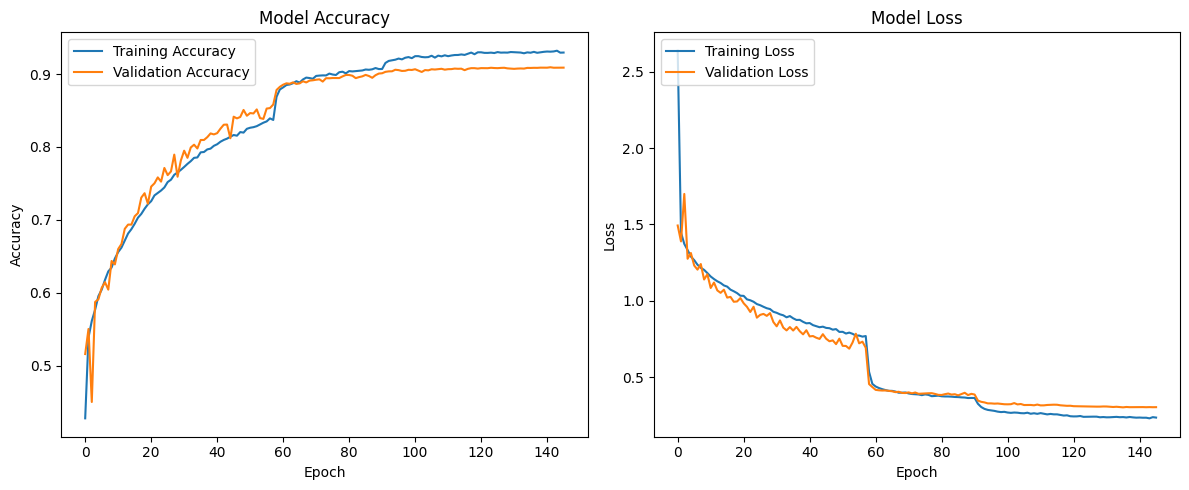

In [27]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [32]:
# predicting on test data.
pred_test = model1.predict(X_test)
# Get the predicted labels (class with highest probability)
y_pred = np.argmax(pred_test, axis=1)  # Get the index of the max value along axis 1
y_pred = label_encoder.inverse_transform(y_pred) # Inverse transform the predicted labels



533/533 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


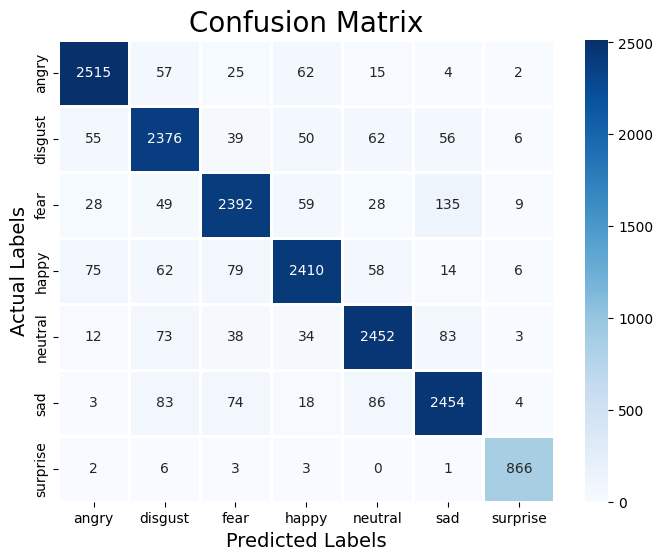

In [33]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8, 6))
# Replace label_encoder.categories_ with label_encoder.classes_
cm = pd.DataFrame(cm , index = [i for i in label_encoder.classes_] , columns = [i for i in label_encoder.classes_])
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.93      0.94      0.94      2680
     disgust       0.88      0.90      0.89      2644
        fear       0.90      0.89      0.89      2700
       happy       0.91      0.89      0.90      2704
     neutral       0.91      0.91      0.91      2695
         sad       0.89      0.90      0.90      2722
    surprise       0.97      0.98      0.97       881

    accuracy                           0.91     17026
   macro avg       0.91      0.92      0.91     17026
weighted avg       0.91      0.91      0.91     17026

